In [56]:
from google.colab import files
files.upload()

Saving test.csv to test.csv


{'test.csv': b'Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather\n0,qp02z1,49,2:15,,1,Not Allowed,No,,\n1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213455442872,Snowy\n2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.31820257526677,Sunny\n3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,,Rainy\n4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.26616222688751,Foggy\n5,qp02zf,49,2:15,Residential,3,Allowed,Yes,8.942256336709507,Rainy\n6,qp08b6,49,2:15,Residential,2,Not Allowed,Yes,21.698032145877587,Sunny\n7,qp02ze,49,2:15,Residential,2,Not Allowed,Yes,27.495912426530733,Sunny\n8,qp08b7,49,2:15,Residential,1,Not Allowed,No,19.555319042610783,Sunny\n9,qp02zs,49,2:15,Residential,3,Allowed,Yes,20.397601078257832,Sunny\n10,qp02zu,49,2:15,Residential,3,Allowed,Yes,13.895097443383456,Rainy\n11,qp08bh,49,2:15,Street,1,Not Allowed,Yes,23.159617759208555,Sunny\n12,qp08bk,49,2:15,Street,1,Not Allowed,Yes,22.927888022343136,Sunny\n13,qp08ck,49,2:15,Resid

In [47]:
import xgboost as xgb
import numpy as np
import pandas as pd

df = pd.read_csv('/content/transformed_train.csv')

#Converting the Timestamp into a cyclical feature
#####We will first convert the strings into minutes ,then use minutes/total_day_minutes to convert into sin and cos time




In [48]:
def to_minutes(str):
  time = str.split(':')
  return int(time[0])*60 + int(time[1])

df['timestamp'] = df['timestamp'].apply(to_minutes)

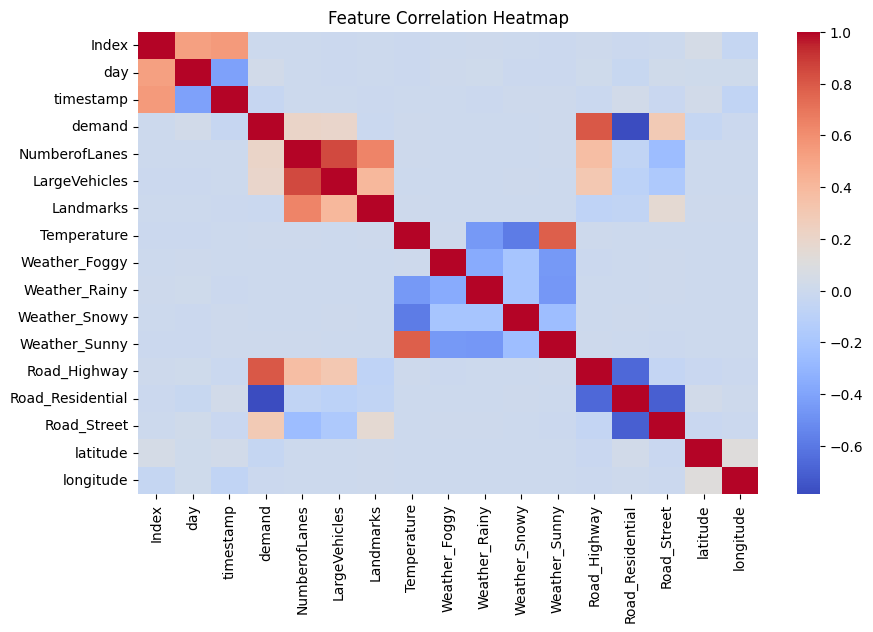

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

####conversion into sin and cos

In [50]:
minutes_in_day = 60*24

df['sin_time'] = df['timestamp'].apply(lambda x : np.sin(2 * x * np.pi / minutes_in_day))
df['cos_time'] = df['timestamp'].apply(lambda x : np.cos(2 * x * np.pi / minutes_in_day))

df.drop(columns = ['timestamp', 'Index'], inplace = True)

### Converting the dataset into X and y and training , test splits


In [51]:
X = df.drop(columns = ['demand']).to_numpy()
y = df['demand'].to_numpy()

In [52]:
df.loc[df['Temperature'] > 40, 'Temperature'] = 40

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
model = xgb.XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    reg_alpha=0.5,
    objective='reg:squarederror',
    device='cuda',  # Uses NVIDIA GPU
    early_stopping_rounds=50
)

print("\nFitting model on GPU...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)


Fitting model on GPU...
[0]	validation_0-rmse:0.13891
[1]	validation_0-rmse:0.13354
[2]	validation_0-rmse:0.12828
[3]	validation_0-rmse:0.12361
[4]	validation_0-rmse:0.11920
[5]	validation_0-rmse:0.11484
[6]	validation_0-rmse:0.11101
[7]	validation_0-rmse:0.10734
[8]	validation_0-rmse:0.10381
[9]	validation_0-rmse:0.10030
[10]	validation_0-rmse:0.09735
[11]	validation_0-rmse:0.09447
[12]	validation_0-rmse:0.09162
[13]	validation_0-rmse:0.08898
[14]	validation_0-rmse:0.08722
[15]	validation_0-rmse:0.08479
[16]	validation_0-rmse:0.08260
[17]	validation_0-rmse:0.08051
[18]	validation_0-rmse:0.07871
[19]	validation_0-rmse:0.07690
[20]	validation_0-rmse:0.07519
[21]	validation_0-rmse:0.07375
[22]	validation_0-rmse:0.07255
[23]	validation_0-rmse:0.07119
[24]	validation_0-rmse:0.06988
[25]	validation_0-rmse:0.06883
[26]	validation_0-rmse:0.06751
[27]	validation_0-rmse:0.06665
[28]	validation_0-rmse:0.06544
[29]	validation_0-rmse:0.06465
[30]	validation_0-rmse:0.06394
[31]	validation_0-rmse:0

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device='cuda', early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=None, num_parallel_tree=None, ...)

In [55]:
preds = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

MSE: 0.001443607888073911
MAE: 0.02612694784089923
R2: 0.9311173392655576


##NOW LET'S PREDICT ON THE TEST SET

In [57]:
!pip install pygeohash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.9 MB/s eta 0:00:00


In [64]:
import pandas as pd
import pygeohash as pgh

def decode_geohash(geohash_string):
    if pd.isna(geohash_string) or str(geohash_string).strip() == '':
        return pd.Series([None, None])
    try:
        lat, lon = pgh.decode(geohash_string)
        return pd.Series([float(lat), float(lon)])
    except:
        return pd.Series([None, None])

def onehotencode_columns(df):
    df_encoded = pd.get_dummies(df, columns=['Weather'], prefix='Weather', dtype=int)
    df_encoded = pd.get_dummies(df_encoded, columns=['RoadType'], prefix='Road', dtype=int)
    df_encoded['LargeVehicles'] = df_encoded['LargeVehicles'].map({'Allowed': 1, 'Not Allowed': 0}).fillna(0)
    df_encoded['Landmarks'] = df_encoded['Landmarks'].map({'Yes': 1, 'No': 0}).fillna(0)

    df_encoded['timestamp'] = df_encoded['timestamp'].apply(to_minutes)
    df_encoded['sin_time'] = df_encoded['timestamp'].apply(lambda x : np.sin(2 * x * np.pi / minutes_in_day))
    df_encoded['cos_time'] = df_encoded['timestamp'].apply(lambda x : np.cos(2 * x * np.pi / minutes_in_day))

    df_encoded.drop(columns = ['timestamp', 'Index'], inplace = True)
    df_encoded['Temperature'] = df_encoded['Temperature'].fillna(df_encoded['Temperature'].mean())
    return df_encoded

def save_lat_lon(df):
    lat_lon = df['geohash'].apply(decode_geohash)
    df['latitude'] = lat_lon[0]
    df['longitude'] = lat_lon[1]
    return df.drop(columns=['geohash'])

def main():
    df = pd.read_csv('/content/test.csv')
    df_encoded = onehotencode_columns(df)
    df_final = save_lat_lon(df_encoded)

    df_final.to_csv('/content/transformed_test.csv', index=False)
    print(df_final.info())

if __name__ == "__main__":
    main()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41778 entries, 0 to 41777
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   day               41778 non-null  int64  
 1   NumberofLanes     41778 non-null  int64  
 2   LargeVehicles     41778 non-null  int64  
 3   Landmarks         41778 non-null  int64  
 4   Temperature       41778 non-null  float64
 5   Weather_Foggy     41778 non-null  int64  
 6   Weather_Rainy     41778 non-null  int64  
 7   Weather_Snowy     41778 non-null  int64  
 8   Weather_Sunny     41778 non-null  int64  
 9   Road_Highway      41778 non-null  int64  
 10  Road_Residential  41778 non-null  int64  
 11  Road_Street       41778 non-null  int64  
 12  sin_time          41778 non-null  float64
 13  cos_time          41778 non-null  float64
 14  latitude          41778 non-null  float64
 15  longitude         41778 non-null  float64
dtypes: float64(5), int64(11)
memory usage: 5

In [66]:
df_final = pd.read_csv('/content/transformed_test.csv')

predictions = model.predict(df_final.to_numpy())

In [73]:
df_preds = pd.DataFrame({'demand': predictions})
df_preds.reset_index()
df_preds.rename({ 'index' : 'Index'})
df_preds

,demand
0,0.183263
1,-0.048414
2,-0.049424
3,-0.055955
4,-0.045385
...,...
41773,0.215787
41774,-0.054321
41775,-0.055538
41776,-0.053680


In [75]:
df_preds.to_csv('/content/predictions.csv', index=True)